In [1]:
# Made by Andrew Butler in Physics 581 class
import numpy as np
from scipy.stats import multivariate_normal
from scipy import integrate
from bs4 import BeautifulSoup
import requests
from scipy.stats import binned_statistic_2d
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
# import knnie #Ensure that convex optimization package (cvxopt) is installed to
# python to use this program
import matplotlib.pyplot as plt

In [3]:
# Scraping Height and Weight Data from Webpage
url = 'http://socr.ucla.edu/docs/resources/SOCR_Data/SOCR_Data_Dinov_020108_HeightsWeights.html'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')
table = soup.find('table')

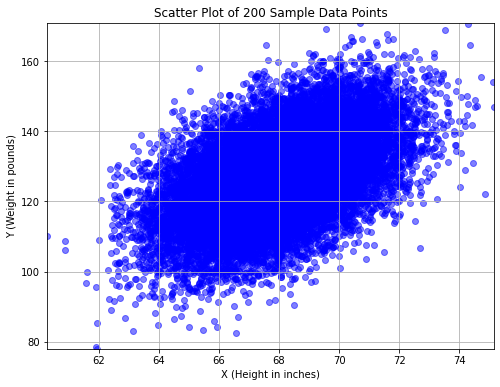

In [17]:
# Format data into numpy arrays
rows = table.find_all('tr')
heights = []
weights = []
for row in rows[1:]:
    cells = row.find_all('td')
    heights.append(float(cells[1].text))
    weights.append(float(cells[2].text))
heights = np.array(heights)
weights = np.array(weights)
data = np.column_stack((heights, weights))

##Extract Sample Data randomly from large dataset
np.random.seed(0) # Set a seed for reproducibility
sample_indices = np.random.choice(len(data), size=20000, replace=False) #Control sample size in "size="
sample_data = data[sample_indices]
min_height = np.min(data[:,0])
max_height = np.max(data[:,0])
min_weight = np.min(data[:,1])
max_weight = np.max(data[:,1])

# Scatter plot of sample data
plt.figure(figsize=(8, 6))
plt.scatter(sample_data[:, 0], sample_data[:, 1], color='blue', alpha=0.5)
plt.title('Scatter Plot of 200 Sample Data Points')
plt.xlabel('X (Height in inches)')
plt.ylabel('Y (Weight in pounds)')
plt.xlim(min_height, max_height)
plt.ylim(min_weight, max_weight)
plt.grid(True)
plt.show()


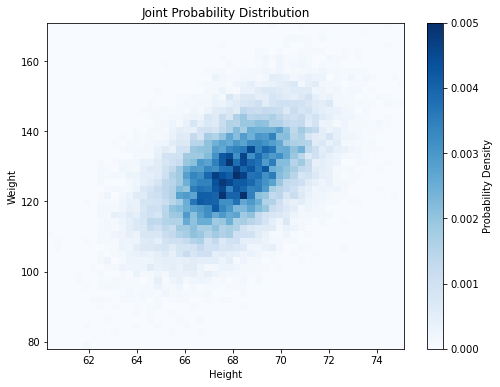

In [18]:
##Binning Approach
# Discretize the continuous variables into bins
num_bins = 50 # Can adjust the number of bins
height_bins = np.linspace(min_height, max_height, num_bins+1)
weight_bins = np.linspace(min_weight, max_weight, num_bins+1)
# Calculate the joint probability distribution
joint_prob_bin, _, _, _ = binned_statistic_2d(sample_data[:,0], sample_data[:,1],
None, 'count', bins=[height_bins, weight_bins])
# Calculate the marginal probability distributions
marginal_height_bin = np.sum(joint_prob_bin, axis=1)
marginal_weight_bin = np.sum(joint_prob_bin, axis=0)
# Normalize
joint_prob_bin /= np.sum(joint_prob_bin)
marginal_height_bin /= np.sum(marginal_height_bin)
marginal_weight_bin /= np.sum(marginal_weight_bin)

# Plot the joint probability distribution
plt.figure(figsize=(8, 6))
plt.imshow(joint_prob_bin.T, origin='lower', extent=[min_height, max_height,
min_weight, max_weight], cmap='Blues', aspect='auto')
plt.colorbar(label='Probability Density')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Joint Probability Distribution')
plt.show()